In [1]:
import BESplotting as bp

import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import pyuda
client = pyuda.Client()
import sys

%matplotlib widget

kk_cz couldnt be imported
dd couldnt be imported


In [2]:
def rolling(arr, w):
    return np.convolve(arr, np.ones(w), mode='same') / w

In [3]:
shotns = [
    51691, 51704, 51705, 51706, 51709, 51710, 51711, 51712, 51713, 51761, 51762, 51763, 51764, 51765
]
boo =    [ 
    False, False, False, False, False, False, False, False,  True, False, False, False, False,  True, 
]
colors = [ 
      'k',  'C0',  'C1',  'C2',  'C3',  'C4',  'C5',  'C6',  'C7',  'C8',  'C9', 'C10', 'C11', 'C12'
]

fuels = [
    '/xdc/flow/s/hfs_mid_u02', 
#     '/xdc/flow/s/lfsv_bot_l03', 
#     '/xdc/flow/s/lfsv_top_u11', 
    '/xdc/flow/s/lfsd_bot_l0506', 
    '/xdc/flow/s/lfsd_top_u0506', 
#     '/xdc/flow/s/pfr_bot_b01', 
#     '/xdc/flow/s/pfr_top_t05', 
    '/xdc/flow/s/hfs_mid_l02', 
]

# puffs = [0.23, 0.71]
puffs = [0.23, 0.35, 0.47, 0.59, 0.71]

time = [None] * len(shotns)
emMax = [None] * len(shotns)
emMaxR = [None] * len(shotns)
n0Max = [None] * len(shotns)
n0MaxR = [None] * len(shotns)
sizMax = [None] * len(shotns)
sizMaxR = [None] * len(shotns)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            
            resultsFile = f'/home/sthoma/Documents/Results/rba/{shotn}/rba_results_neutral.npz'
            results = np.load(resultsFile)

            time[i] = results['time']
            emMax[i] = results['emMax']
            emMaxR[i] = results['emMaxR']
            n0Max[i] = results['neutralMax']
            n0MaxR[i] = results['neutralMaxR']
            sizMax[i] = results['ioniseMax']
            sizMaxR[i] = results['ioniseMaxR']

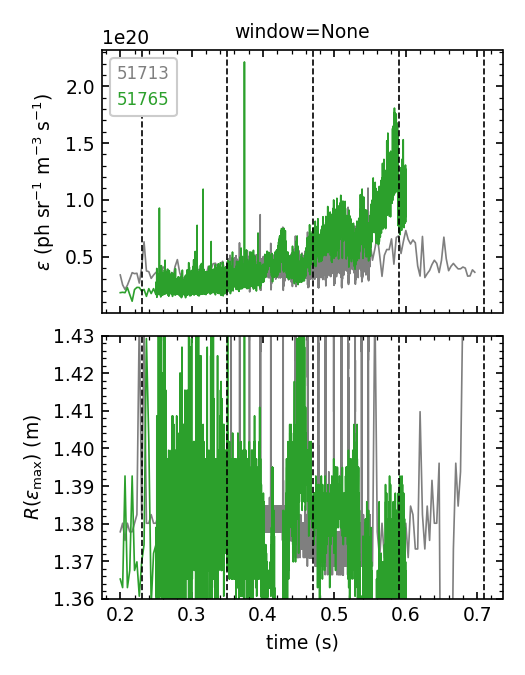

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            ax[0].plot(time[i], emMax[i], c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], emMaxR[i], c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_title('window=None', fontsize=9)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{max})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.43])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

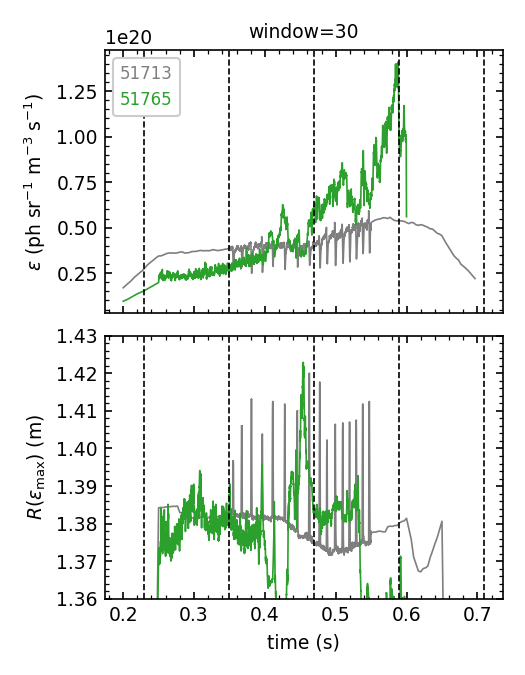

In [5]:
w = 30
    

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            
            emMaxAverage = rolling(emMax[i], w)
            emMaxRAverage = rolling(emMaxR[i], w)
            
            ax[0].plot(time[i], emMaxAverage, c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], emMaxRAverage, c=colors[i], lw=0.8, label=shotn)


ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_title(f'window={w}', fontsize=9)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{max})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.43])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

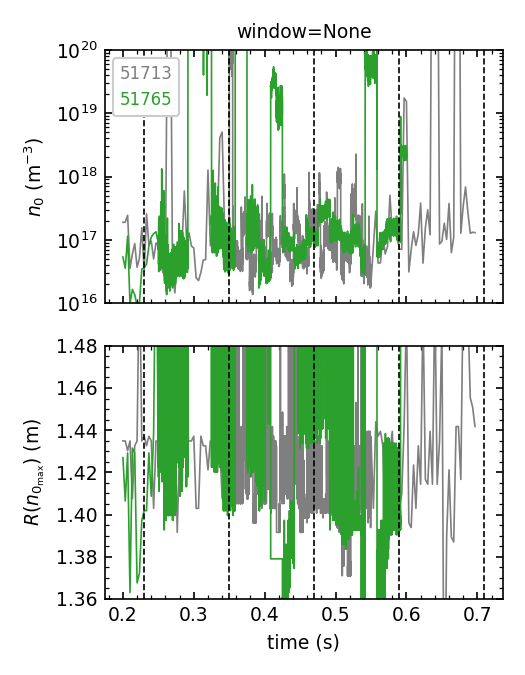

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            ax[0].plot(time[i], n0Max[i], c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], n0MaxR[i], c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)
ax[0].set_title('window=None', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([1e16,1e20])


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(n_{0_\\mathrm{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.48])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

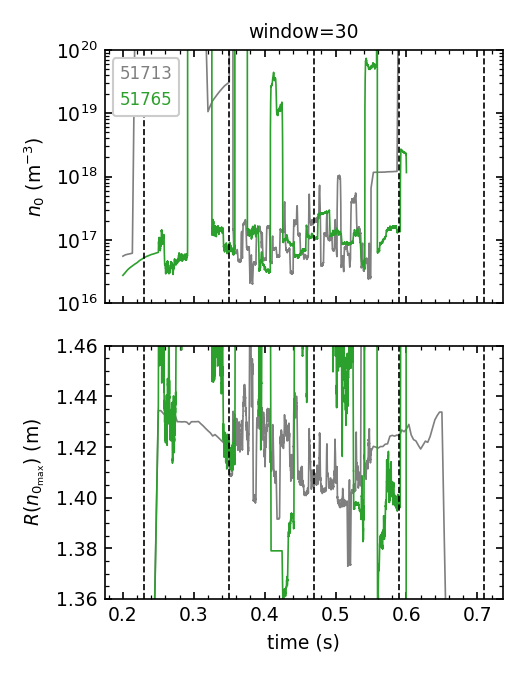

In [7]:
w = 30
 

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            
            n0MaxAverage = rolling(n0Max[i], w)
            n0MaxRAverage = rolling(n0MaxR[i], w)
            
            ax[0].plot(time[i], n0MaxAverage, c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], n0MaxRAverage, c=colors[i], lw=0.8, label=shotn)


ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)
ax[0].set_title(f'window={w}', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([1e16,1e20])


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(n_{0_\\mathrm{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.46])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

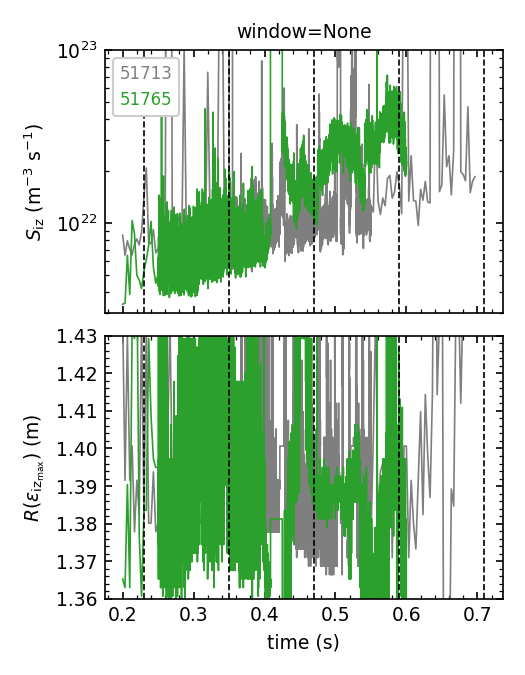

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            ax[0].plot(time[i], sizMax[i], c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], sizMaxR[i], c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([3e21,1e23])
ax[0].set_title('window=None', fontsize=9)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{iz_{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.43])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

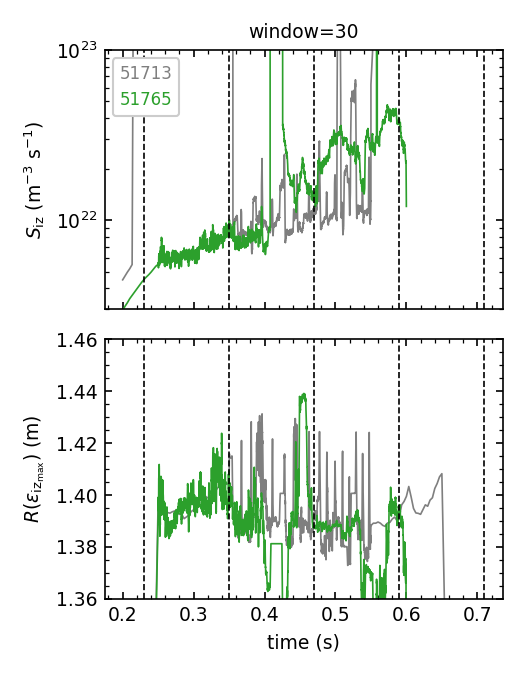

In [9]:
w = 30
 

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        if shotn != 51762:
            
            sizMaxAverage = rolling(sizMax[i], w)
            sizMaxRAverage = rolling(sizMaxR[i], w)
            
            ax[0].plot(time[i], sizMaxAverage, c=colors[i], lw=0.8, label=shotn)
            ax[1].plot(time[i], sizMaxRAverage, c=colors[i], lw=0.8, label=shotn)


ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_title(f'window={w}', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([3e21,1e23])


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{iz_{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.46])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

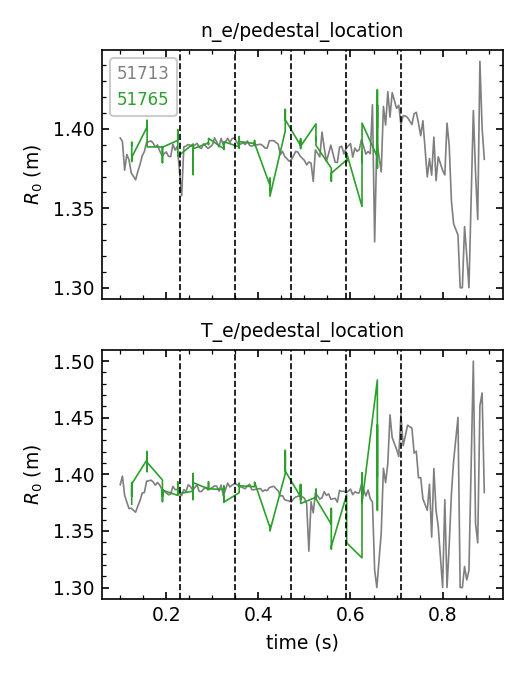

In [10]:
dataString0 = 'n_e/pedestal_location'
ylabel0 = '$R_0$ (m)'
dataString1 = 'T_e/pedestal_location'
ylabel1 = '$R_0$ (m)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

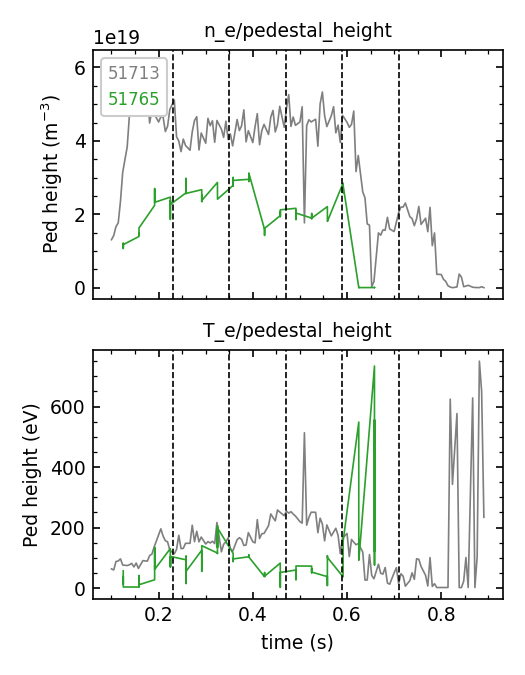

In [11]:
dataString0 = 'n_e/pedestal_height'
ylabel0 = 'Ped height (m$^{-3}$)'
dataString1 = 'T_e/pedestal_height'
ylabel1 = 'Ped height (eV)'

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

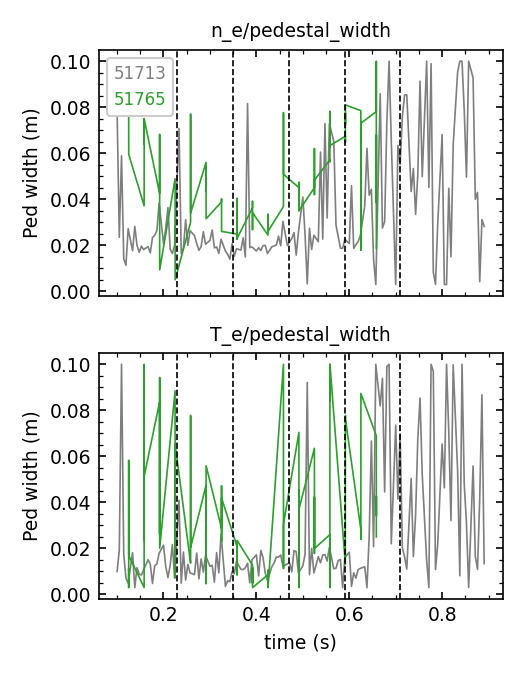

In [12]:
dataString0 = 'n_e/pedestal_width'
ylabel0 = 'Ped width (m)'
dataString1 = 'T_e/pedestal_width'
ylabel1 = 'Ped width (m)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

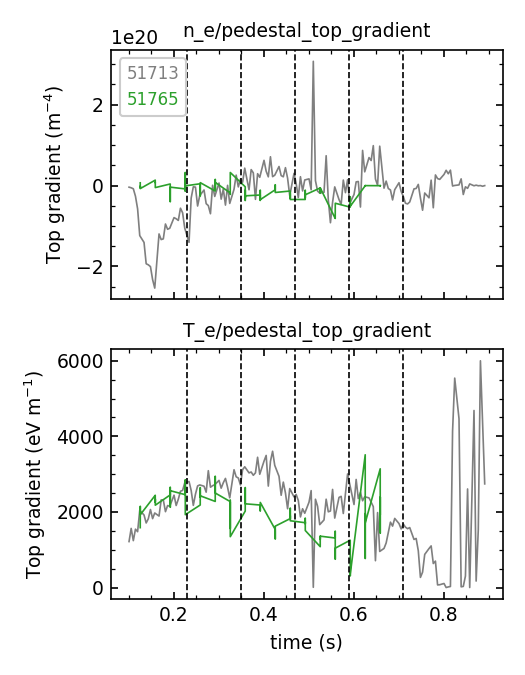

In [13]:
dataString0 = 'n_e/pedestal_top_gradient'
ylabel0 = 'Top gradient (m$^{-4}$)'
dataString1 = 'T_e/pedestal_top_gradient'
ylabel1 = 'Top gradient (eV m$^{-1}$)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

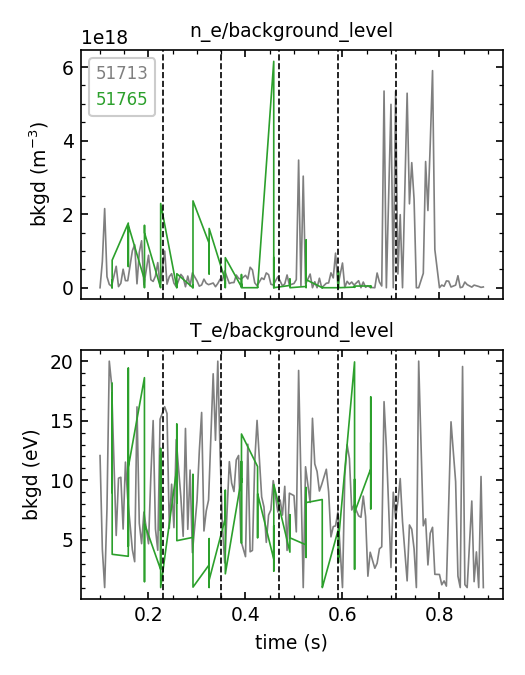

In [14]:
dataString0 = 'n_e/background_level'
ylabel0 = 'bkgd (m$^{-3}$)'
dataString1 = 'T_e/background_level'
ylabel1 = 'bkgd (eV)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=colors[i], lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

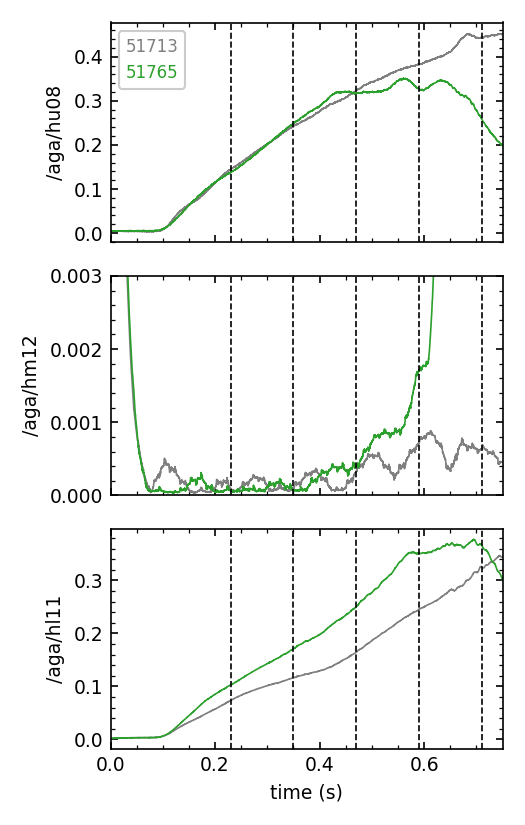

In [15]:
figUpper = '/aga/hu08'
figMid = '/aga/hm12'
figLower = '/aga/hl11'

fig, ax = plt.subplots(3, 1, figsize=(3.5,5.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        figU = client.get('/aga/hu08', shotn)
        ax[0].plot(figU.time.data, figU.data, c=colors[i], lw=0.8, label=shotn)
        figM = client.get('/aga/hm12', shotn)
        ax[1].plot(figM.time.data, figM.data, c=colors[i], lw=0.8, label=shotn)
        figL = client.get('/aga/hl11', shotn)
        ax[2].plot(figL.time.data, figL.data, c=colors[i], lw=0.8, label=shotn)
        

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylabel(figUpper, fontsize=9)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_ylabel(figMid, fontsize=9)


ax[2].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[2].minorticks_on()
ax[2].yaxis.get_offset_text().set_size(9)
ax[2].set_xlabel('time (s)', fontsize=9)
ax[2].set_ylabel(figLower, fontsize=9)

ax[0].set_xlim([0.0, 0.75])
ax[1].set_ylim([0, 0.003])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

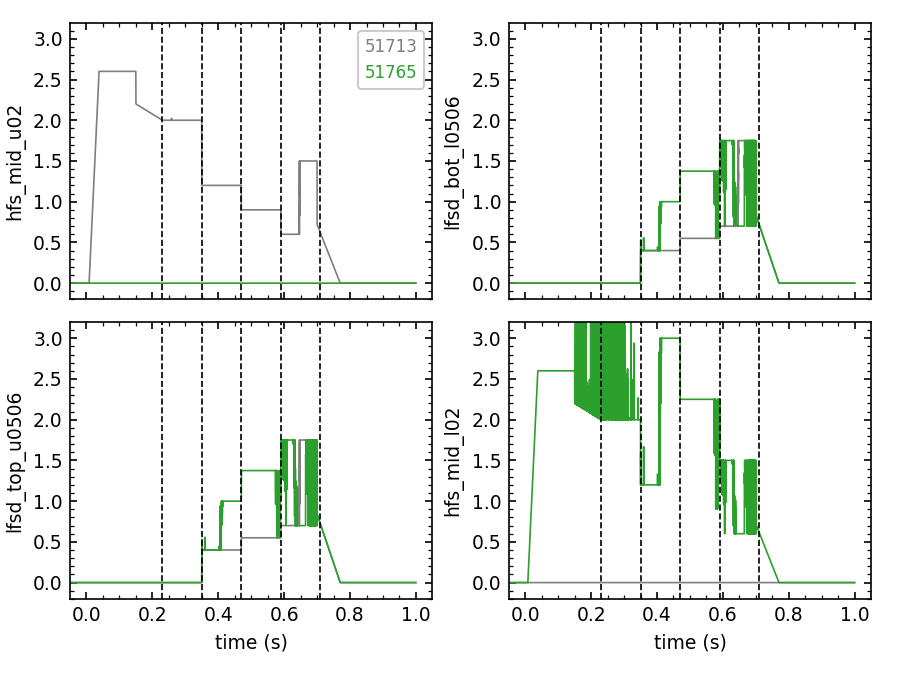

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(6,4.5), dpi=150, sharex=True)

I = 0
II = 0
JJ = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II,JJ].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[II,JJ].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper right', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[II,JJ].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II,JJ].minorticks_on()
ax[II,JJ].yaxis.get_offset_text().set_size(9)
ax[II,JJ].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II,JJ].set_ylim([-0.2, 3.2])


I = 1
II = 0
JJ = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II,JJ].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[II,JJ].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II,JJ].minorticks_on()
ax[II,JJ].yaxis.get_offset_text().set_size(9)
ax[II,JJ].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II,JJ].set_ylim([-0.2, 3.2])


I = 2
II = 1
JJ = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II,JJ].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[II,JJ].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II,JJ].minorticks_on()
ax[II,JJ].yaxis.get_offset_text().set_size(9)
ax[II,JJ].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II,JJ].set_xlabel('time (s)', fontsize=9)
ax[II,JJ].set_xlim([-0.05,1.05])
ax[II,JJ].set_ylim([-0.2, 3.2])

I = 3
II = 1
JJ = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II,JJ].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[II,JJ].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II,JJ].minorticks_on()
ax[II,JJ].yaxis.get_offset_text().set_size(9)
ax[II,JJ].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II,JJ].set_xlabel('time (s)', fontsize=9)
ax[II,JJ].set_xlim([-0.05,1.05])
ax[II,JJ].set_ylim([-0.2, 3.2])


for AX in ax.flatten():
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')


plt.tight_layout()

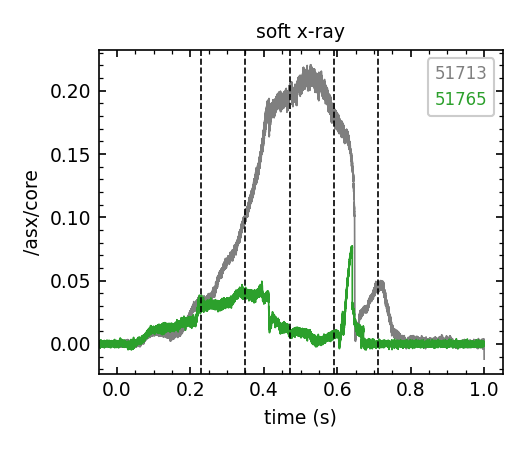

In [17]:
sxr = '/asx/core'

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150, sharex=True)

I = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(sxr, shotn)
        ax.plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax.legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper right', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_ylabel(sxr, fontsize=9)
ax.set_xlabel('time (s)', fontsize=9)
ax.set_xlim([-0.05,1.05])
# ax.set_ylim([-0.2, 3.2])
ax.set_title('soft x-ray', fontsize=9)


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')


plt.tight_layout()

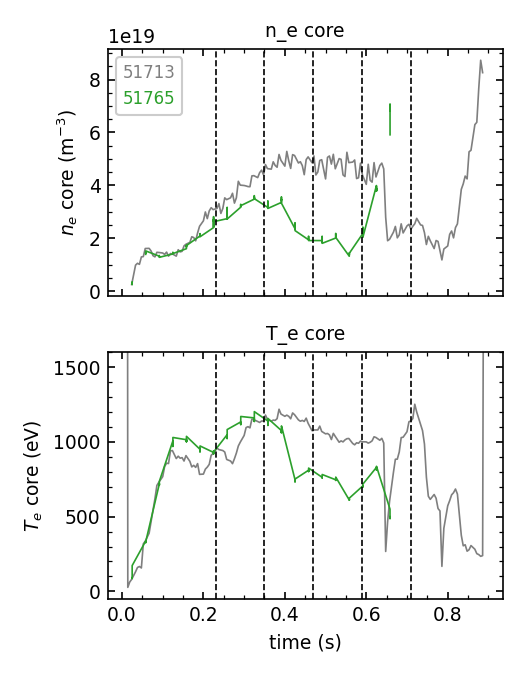

In [18]:
ne = '/AYC/N_E_CORE'
Te = '/AYC/T_E_CORE'

dataString0 = 'n_e core'
ylabel0 = '$n_e$ core (m$^{-3}$)'
dataString1 = 'T_e core'
ylabel1 = '$T_e$ core (eV)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(ne, shotn)
        ax[0].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)


for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(Te, shotn)
        ax[1].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)
ax[1].set_ylim([-50,1600.])


for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')


plt.tight_layout()

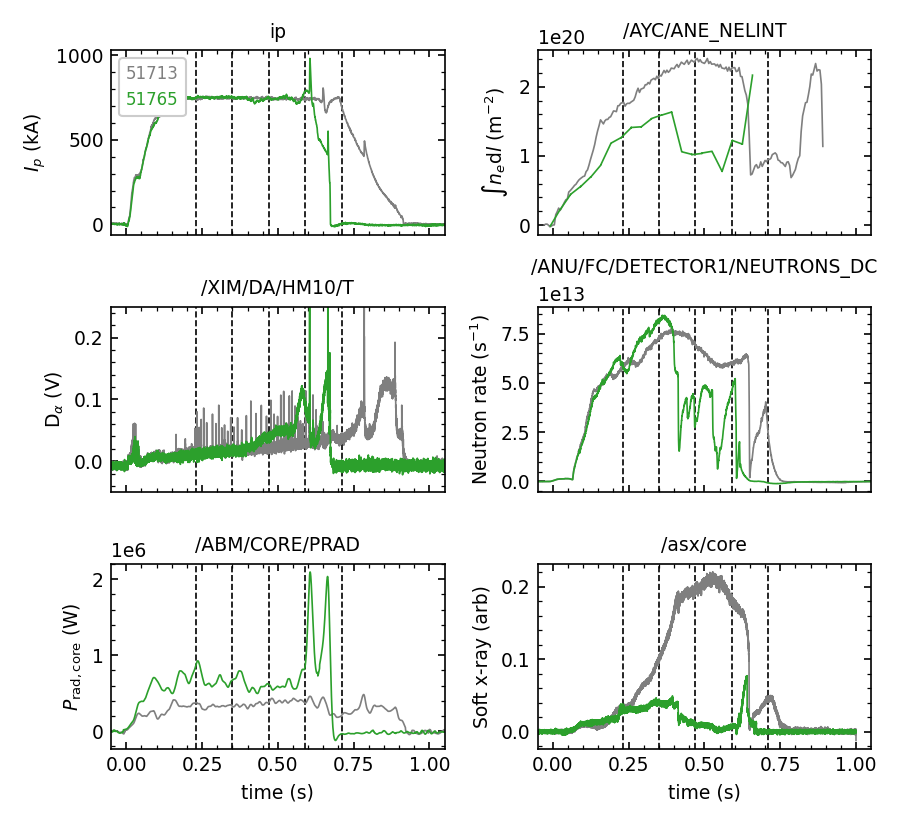

In [19]:
ip = 'ip'
ylabel0 = '$I_p$ (kA)'
neLine = '/AYC/ANE_NELINT'
ylabel1 = '$\\int n_e \\mathrm{d}l$ (m$^{-2}$)'
dalpha = '/XIM/DA/HM10/T'
ylabel2 = '$\\mathrm{D}_\\alpha$ (V)'
neutrons = '/ANU/FC/DETECTOR1/NEUTRONS_DC'
ylabel3 = 'Neutron rate (s$^{-1}$)'
prad = '/ABM/CORE/PRAD'
ylabel4 = '$P_\\mathrm{rad,core}$ (W)'
sxr = '/asx/core'
ylabel5 = 'Soft x-ray (arb)'

fig, ax = plt.subplots(3, 2, figsize=(6,5.5), dpi=150, sharex=True)

I = 0
J = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(ip, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)
ax[I,J].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_ylabel(ylabel0, fontsize=9)
ax[I,J].set_title(f'{ip}', fontsize=9)


I = 0
J = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(neLine, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_ylabel(ylabel1, fontsize=9)
ax[I,J].set_title(f'{neLine}', fontsize=9)


I = 1
J = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(dalpha, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_ylabel(ylabel2, fontsize=9)
ax[I,J].set_title(f'{dalpha}', fontsize=9)


I = 1
J = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(neutrons, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_ylabel(ylabel3, fontsize=9)
ax[I,J].set_title(f'{neutrons}', fontsize=9)


I = 2
J = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(prad, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_xlabel('time (s)', fontsize=9)
ax[I,J].set_ylabel(ylabel4, fontsize=9)
ax[I,J].set_title(f'{prad}', fontsize=9)


I = 2
J = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(sxr, shotn)
        ax[I,J].plot(d.time.data, d.data, c=colors[i], lw=0.8, label=shotn)

ax[I,J].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[I,J].minorticks_on()
ax[I,J].yaxis.get_offset_text().set_size(9)
ax[I,J].set_xlabel('time (s)', fontsize=9)
ax[I,J].set_ylabel(ylabel5, fontsize=9)
ax[I,J].set_title(f'{sxr}', fontsize=9)


ax[I,J].set_xlim([-0.05,1.05])

for AX in ax.flatten():
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--', zorder=0)
ax[1,0].set_ylim([-0.05, 0.25])

plt.tight_layout()